In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/baseline-artifacts/thresholds.json
/kaggle/input/baseline-artifacts/df_resid.parquet
/kaggle/input/baseline-artifacts/df_pred.parquet
/kaggle/input/baseline-artifacts/df_wide.parquet
/kaggle/input/caf-dataset/CAF_sensors.dbf
/kaggle/input/caf-dataset/Hourly/Hourly/CAF141.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF019.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF209.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF007.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF397.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF237.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF205.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF125.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF139.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF095.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF201.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF215.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF079.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF231.txt
/kaggle/input/caf-dataset/Hourly/Hourly/CAF275.

# Data and Preprocessing

In [2]:
# ================= CONFIG =================
# ================= CONFIG =================
SEED = 42
WINDOW = 24
K_NEIGHBORS = 4

# Fault belief threshold (control-level, not detection)
p_fault_threshold = 0.6


import numpy as np
import pandas as pd
import torch
import random
import matplotlib.pyplot as plt

np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)


In [3]:
# ================= DATA LOAD =================
df_wide = pd.read_parquet(
    "/kaggle/input/baseline-artifacts/df_wide.parquet"
)

df_wide = df_wide.sort_index()
sensor_ids = df_wide.columns.tolist()

T, N = df_wide.shape
print("Time steps:", T)
print("Sensors:", N)


Time steps: 66705
Sensors: 10


In [4]:
# interpolate only short gaps
df_filled = df_wide.interpolate(
    limit=6,                 # e.g. 6 timesteps
    limit_direction="both"
)

# fallback: per-sensor median (more robust than mean)
df_filled = df_filled.fillna(df_filled.median())

assert not df_filled.isna().any().any(), "❌ NaNs still present"


In [5]:
X_np = df_filled.values.astype(np.float32)

mean = X_np.mean(axis=0, keepdims=True)
std  = X_np.std(axis=0, keepdims=True) + 1e-6

X_np = (X_np - mean) / std
X = torch.tensor(X_np, dtype=torch.float32)
X = X.contiguous()


assert torch.isfinite(X).all()


In [6]:
assert 'X' in globals(), "X not defined — run preprocessing cell"


In [7]:
# ================= SENSOR METADATA =================
import geopandas as gpd
import numpy as np

DBF_PATH = "/kaggle/input/caf-dataset/CAF_sensors.dbf"
gdf = gpd.read_file(DBF_PATH)

# Keep only required columns
sensor_meta = gdf[["Location", "Easting", "Northing"]].copy()

# Set index for alignment
sensor_meta = sensor_meta.set_index("Location")

# ---- sanity check: all sensors present ----
missing = set(sensor_ids) - set(sensor_meta.index)
assert len(missing) == 0, f"❌ Missing sensor metadata for: {missing}"

# ---- extract coordinates in correct order ----
coords = sensor_meta.loc[sensor_ids, ["Easting", "Northing"]].values

print("Coord ranges:", coords.min(axis=0), coords.max(axis=0))

# ---- final sanity checks ----
assert coords.shape == (N, 2)
assert np.isfinite(coords).all()


Coord ranges: [ 493247 5180568] [ 494024 5180678]


In [8]:
# ================= SPATIAL GRAPH =================
from sklearn.neighbors import NearestNeighbors
import numpy as np

nbrs = NearestNeighbors(
    n_neighbors=K_NEIGHBORS + 1,
    metric="euclidean"
).fit(coords)

distances, indices = nbrs.kneighbors(coords)

# Remove self-loops (first neighbor is the point itself)
neighbors = indices[:, 1:]        # (N, K)
neighbor_dist = distances[:, 1:]  # (N, K)

assert neighbors.shape == (N, K_NEIGHBORS)
assert neighbor_dist.shape == (N, K_NEIGHBORS)

# ================= ASYMMETRY CHECK =================
asym = 0

for i in range(N):
    for j in neighbors[i]:
        j = int(j)  # ensure Python int
        if i not in neighbors[j]:
            asym += 1

print(f"Asymmetric edges: {asym}")


Asymmetric edges: 10


In [9]:
# ================= NEIGHBOR HEALTH TRUST =================
# health[j] = long-term agreement of sensor j with its neighbors

X_np = X.detach().cpu().numpy()   # (T, N), clean & normalized
health = np.zeros(N, dtype=np.float32)

for j in range(N):
    nbrs = neighbors[j]          # (K,)

    # Safety: skip if no neighbors (should not happen with kNN)
    if len(nbrs) == 0:
        health[j] = 0.0
        continue

    # Median neighbor signal at each time step → (T,)
    nbr_median = np.median(X_np[:, nbrs], axis=1)

    # Absolute deviation over time → (T,)
    deviation = np.abs(X_np[:, j] - nbr_median)

    # Robust aggregation (median over time)
    health[j] = np.exp(-np.median(deviation))

# Normalize to [0, 1]
health = health / (health.max() + 1e-6)

health = torch.tensor(health, dtype=torch.float32)

# Sanity checks
assert health.shape == (N,)
assert torch.isfinite(health).all()


In [10]:
# ================= DISTANCE-WEIGHTED ADJ =================

A = np.zeros((N, N), dtype=np.float32)
eps = 1e-6

for i in range(N):
    nbrs = neighbors[i]
    dists = neighbor_dist[i]

    for j, d in zip(nbrs, dists):
        w = 1.0 / (d + eps)
        A[i, j] = w
        A[j, i] = w   # enforce symmetry

# self-loops (important for stability)
np.fill_diagonal(A, 1.0)

# ---- row normalization with safety ----
row_sum = A.sum(axis=1, keepdims=True)
row_sum[row_sum == 0.0] = 1.0   # safety guard

A = A / row_sum

# convert to torch
A = torch.tensor(A, dtype=torch.float32)

# sanity checks
assert A.shape == (N, N)
assert torch.isfinite(A).all()
assert torch.allclose(A.sum(dim=1), torch.ones(N), atol=1e-5), "❌ Bad normalization"


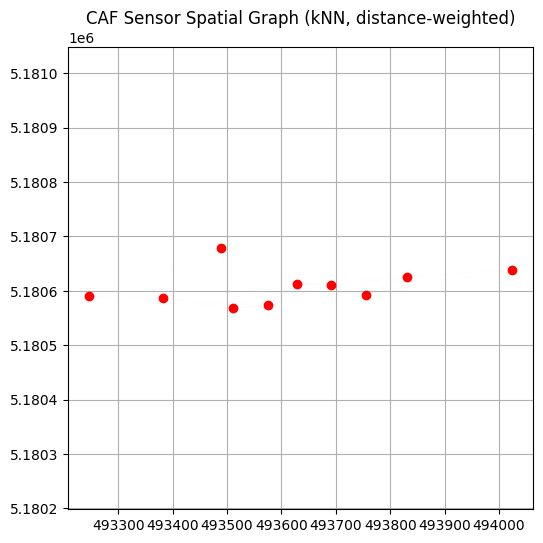

In [11]:
plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], c="red", zorder=3)

drawn = set()

for i in range(N):
    for j, d in zip(neighbors[i], neighbor_dist[i]):
        if (j, i) in drawn:
            continue
        drawn.add((i, j))

        lw = 2.0 / (d + 1e-3)   # closer = thicker
        plt.plot(
            [coords[i,0], coords[j,0]],
            [coords[i,1], coords[j,1]],
            color="gray",
            alpha=0.6,
            linewidth=lw,
            zorder=1
        )

plt.title("CAF Sensor Spatial Graph (kNN, distance-weighted)")
plt.axis("equal")
plt.grid(True)
plt.show()


# Fault Injection

In [12]:
FAULT_SENSOR = 2
FAULT_START  = 20000
FAULT_END    = 20500
FAULT_MAG    = 5.0

assert 0 <= FAULT_SENSOR < N
assert 0 <= FAULT_START < FAULT_END <= T


In [13]:
# ================= FAULT GROUND TRUTH =================
T, N = X.shape

fault_gt = torch.zeros((T, N), dtype=torch.bool)
fault_gt[FAULT_START:FAULT_END, FAULT_SENSOR] = True

print("Total faulted samples:", fault_gt.sum().item())

assert fault_gt[:, FAULT_SENSOR].sum() == (FAULT_END - FAULT_START)
assert fault_gt.sum() == (FAULT_END - FAULT_START)


Total faulted samples: 500


In [14]:
s = FAULT_SENSOR


In [15]:
# ================= FAULT INJECTION =================
X_fault = X.clone()
X_fault[FAULT_START:FAULT_END, FAULT_SENSOR] += FAULT_MAG

assert torch.isfinite(X_fault).all()
assert 0 <= FAULT_SENSOR < X.shape[1]
assert 0 <= FAULT_START < FAULT_END <= X.shape[0]


In [16]:
delta = X_fault - X
assert torch.all(
    (delta[:, FAULT_SENSOR] != 0) == fault_gt[:, FAULT_SENSOR]
)


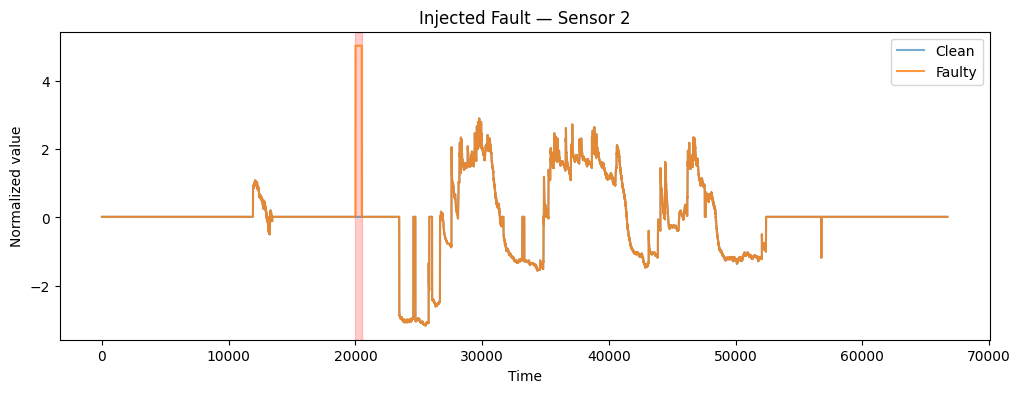

In [17]:
plt.figure(figsize=(12,4))
plt.plot(X[:, s].cpu(), label="Clean", alpha=0.6)
plt.plot(X_fault[:, s].cpu(), label="Faulty", alpha=0.8)
plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)

plt.xlabel("Time")
plt.ylabel("Normalized value")
plt.legend()
plt.title(f"Injected Fault — Sensor {s}")
plt.show()


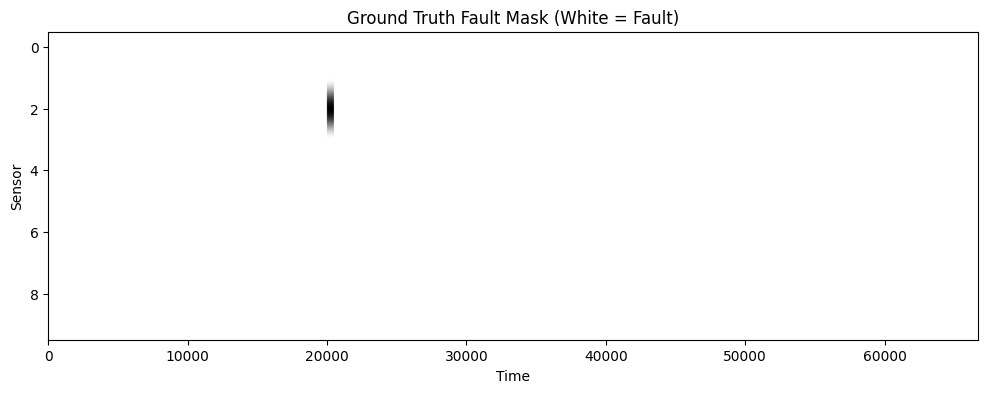

In [18]:
plt.figure(figsize=(12,4))
plt.imshow(
    fault_gt.T.cpu(),
    aspect="auto",
    cmap="gray_r"
)
plt.xlabel("Time")
plt.ylabel("Sensor")
plt.title("Ground Truth Fault Mask (White = Fault)")
plt.show()


In [19]:
# ================= SPATIAL BASELINE PREDICTOR =================
A_np = A.cpu().numpy()

def spatial_predictor(X, A):
    """
    X: (T, N)
    A: (N, N) adjacency (row-normalized)
    """
    return X @ A.T


In [20]:
# ================= PREDICTIONS & RESIDUALS =================
pred_spatial = spatial_predictor(X_fault, A)

residuals = torch.abs(X_fault - pred_spatial)
res_np = residuals.cpu().numpy()


In [21]:
assert residuals.shape == X.shape


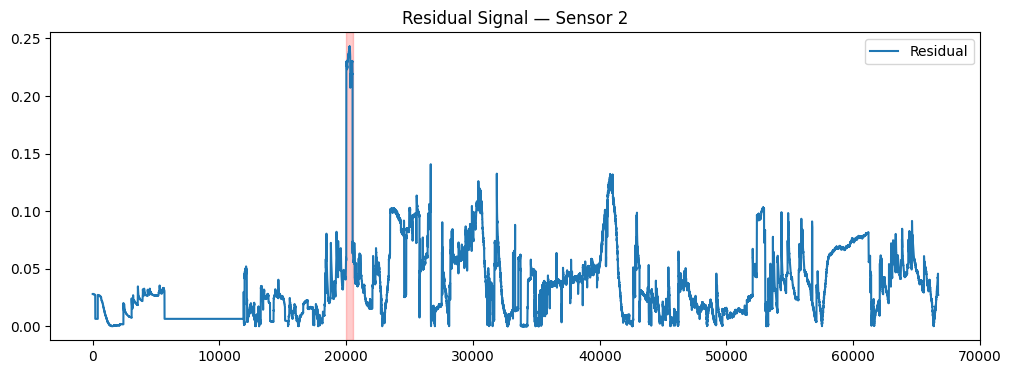

In [22]:
s = FAULT_SENSOR

plt.figure(figsize=(12,4))
plt.plot(res_np[:, s], label="Residual")
plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title(f"Residual Signal — Sensor {s}")
plt.show()


In [23]:
# ================= ROBUST THRESHOLDS =================
res_np = residuals.cpu().numpy()

median = np.nanmedian(res_np, axis=0)
mad = np.nanmedian(np.abs(res_np - median), axis=0)

THRESH = median + 4.0 * mad   # conservative


In [24]:
# ================= PROBABILISTIC FAULT DETECTION =================
eps = 1e-6
alpha = 4.0      # sharpness
beta  = 1.0      # soft threshold
lambda_mem = 0.95

res = res_np  # (T, N)

median = np.nanmedian(res, axis=0)
mad = np.nanmedian(np.abs(res - median), axis=0) + eps

# normalized residual score
z = (res - median) / mad
z = np.clip(z, 0, None)

# instantaneous fault likelihood
p_inst = 1.0 / (1.0 + np.exp(-alpha * (z - beta)))

# temporal belief propagation
p_fault = np.zeros_like(p_inst)

for t in range(T):
    if t == 0:
        p_fault[t] = p_inst[t]
    else:
        p_fault[t] = (
            lambda_mem * p_fault[t-1]
            + (1 - lambda_mem) * p_inst[t]
        )

assert np.all((p_fault >= 0) & (p_fault <= 1))


In [25]:
def spatial_fault_coupling(
    p_fault,
    nbr_idx,
    coupling_strength=0.5
):
    """
    Spatial smoothing of fault belief to avoid isolated false alarms
    """
    T, N = p_fault.shape
    p_coupled = np.zeros_like(p_fault)

    for t in range(T):
        for i in range(N):
            nbrs = nbr_idx[i]

            if len(nbrs) == 0:
                p_coupled[t, i] = p_fault[t, i]
                continue

            nbr_mean = np.mean(p_fault[t, nbrs])

            p_coupled[t, i] = (
                (1.0 - coupling_strength) * p_fault[t, i]
                + coupling_strength * nbr_mean
            )

    return np.clip(p_coupled, 0.0, 1.0)


In [26]:
# ================= STEP 3: SPATIAL FAULT COUPLING =================
p_fault_raw = p_fault.copy()   # keep original for diagnostics

p_fault = spatial_fault_coupling(
    p_fault,
    neighbors,        # ← use neighbors from kNN graph
    coupling_strength=0.5
)



In [27]:
# === Freeze beliefs ===
p_fault_uncoupled = p_fault_raw        # before spatial coupling
p_fault_coupled   = p_fault            # after spatial coupling


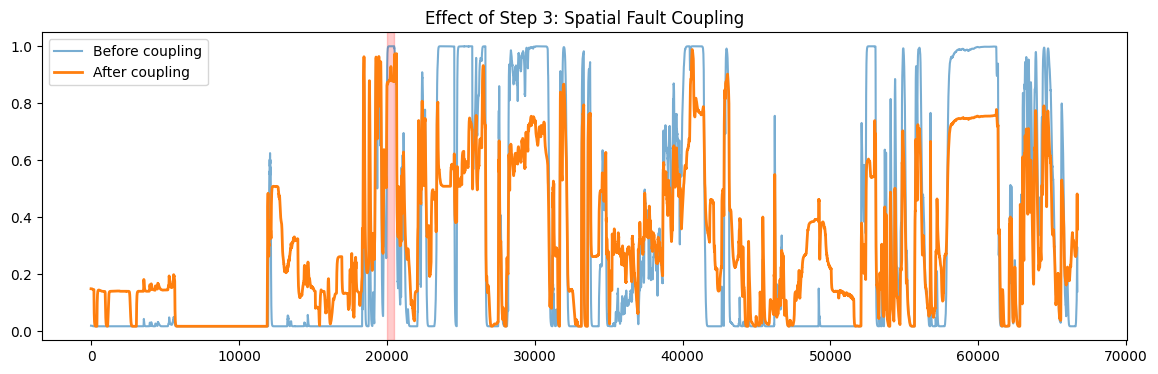

In [28]:
plt.figure(figsize=(14,4))
plt.plot(p_fault_raw[:, s], label="Before coupling", alpha=0.6)
plt.plot(p_fault[:, s], label="After coupling", linewidth=2)
plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Effect of Step 3: Spatial Fault Coupling")
plt.show()


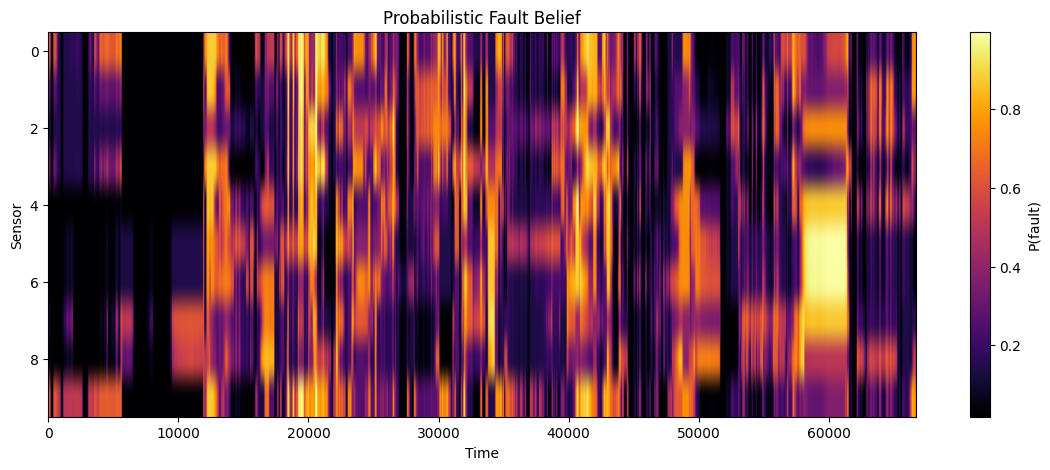

In [29]:
plt.figure(figsize=(14,5))
plt.imshow(p_fault.T, aspect="auto", cmap="inferno")
plt.colorbar(label="P(fault)")
plt.title("Probabilistic Fault Belief")
plt.xlabel("Time")
plt.ylabel("Sensor")
plt.show()


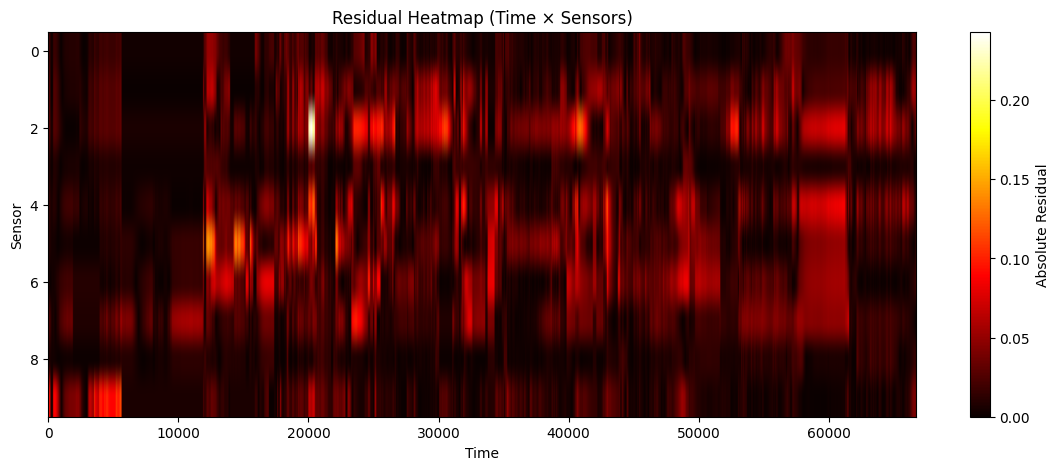

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.imshow(
    res_np.T,
    aspect="auto",
    cmap="hot"
)
plt.colorbar(label="Absolute Residual")
plt.xlabel("Time")
plt.ylabel("Sensor")
plt.title("Residual Heatmap (Time × Sensors)")
plt.show()


In [31]:
y_true = fault_gt.cpu().numpy().reshape(-1).astype(int)
y_score = p_fault.reshape(-1)


In [32]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_true, y_score)
print(f"ROC-AUC: {auc:.3f}")


ROC-AUC: 0.977


In [33]:
def neighbor_fault_probability(
    t,
    target,
    X_obs,
    X_temp_hat,
    p_fault,
    nbr_idx,
    health,
    tau=0.7,
    eps=1e-6
):
    """
    Step-2 FIXED:
    Relative neighbor anomaly scoring (rank-based)
    """

    nbrs = nbr_idx[target]
    x_nbr = X_obs[t, nbrs]

    # disagreement terms
    d_temp = torch.abs(x_nbr - X_temp_hat[t, target])
    consensus = torch.median(x_nbr)
    d_cons = torch.abs(x_nbr - consensus)

    # combined deviation
    score = d_temp + d_cons

    # ---- RELATIVE NORMALIZATION (CRITICAL FIX) ----
    score = score - torch.median(score)
    score = score / (torch.median(torch.abs(score)) + eps)

    # soft ranking → probabilities
    p = torch.sigmoid(score / tau)

    # health prior (do NOT overpower)
    p = p * (0.4 + 0.6 * (1.0 - health[nbrs]))

    return torch.clamp(p, 0.0, 1.0)


In [34]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(y_true, y_score)
print(f"PR-AUC: {ap:.3f}")


PR-AUC: 0.015


In [35]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


In [36]:
# ========= GLOBAL CONFIG =========
sensor_idx = 2
W = 24
t_start = 20000
t_end = 20500
# ================================



# Temporal Only

In [37]:
class TemporalDataset(Dataset):
    def __init__(self, series, window):
        self.series = series
        self.window = window

    def __len__(self):
        return len(self.series) - self.window

    def __getitem__(self, i):
        x = self.series[i:i+self.window]
        y = self.series[i+self.window]
        return x.unsqueeze(-1), y


In [38]:
# ================= CLEAN & FAULT DATA =================

# Clean (normalized, no fault)
X_clean = X.clone()          # X was your normalized df_filled tensor

# Faulty (normalized, injected fault)
X_fault = X_fault.clone()    # from inject_bias(...)


In [39]:
print(X_clean.shape, X_fault.shape)
assert X_clean.shape == X_fault.shape


torch.Size([66705, 10]) torch.Size([66705, 10])


In [40]:
train_ds = TemporalDataset(X_clean[:, sensor_idx], W)
test_ds  = TemporalDataset(X_fault[:, sensor_idx], W)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=64, shuffle=False)


In [41]:
class TemporalGRU(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.gru = nn.GRU(1, hidden, batch_first=True)
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):
        _, h = self.gru(x)
        return self.fc(h.squeeze(0)).squeeze(-1)


In [42]:
model = TemporalGRU()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


## NOTE:
### Temporal model is trained on clean data.
### This is acceptable for reconstruction benchmarking,
### but NOT for online fault detection claims.


In [43]:
for epoch in range(10):
    total = 0
    for x, y in train_loader:
        pred = model(x)
        loss = loss_fn(pred, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += loss.item()

    print(f"Epoch {epoch+1}: {total/len(train_loader):.6f}")


Epoch 1: 0.028455
Epoch 2: 0.001590
Epoch 3: 0.001337
Epoch 4: 0.001199
Epoch 5: 0.001101
Epoch 6: 0.001051
Epoch 7: 0.001014
Epoch 8: 0.001024
Epoch 9: 0.000997
Epoch 10: 0.000997


In [44]:
model.eval()
preds = []

with torch.no_grad():
    for x, _ in test_loader:
        preds.append(model(x))

preds = torch.cat(preds)


In [45]:
# ================= TEMPORAL RECONSTRUCTION (CORRECT) =================

T, N = X_fault.shape
X_temp_hat = X_fault.clone()   # fallback is faulty signal

# preds shape: (T-W,) for single sensor
X_temp_hat[W:, sensor_idx] = preds.squeeze()

# sanity checks
assert X_temp_hat.shape == X_fault.shape
assert not torch.isnan(X_temp_hat).any()


In [46]:
true_clean = X_clean[W:, sensor_idx]
faulty_obs = X_fault[W:, sensor_idx]

rmse_faulty = torch.sqrt(((faulty_obs - true_clean)**2).mean())
rmse_temp   = torch.sqrt(((preds - true_clean)**2).mean())

print("RMSE faulty:", rmse_faulty.item())
print("RMSE temporal:", rmse_temp.item())


RMSE faulty: 0.4329661428928375
RMSE temporal: 0.37604475021362305


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(true_clean, label="True clean", alpha=0.6)
plt.plot(faulty_obs, label="Faulty", alpha=0.4)
plt.plot(preds, label="Temporal reconstruction", linewidth=2)

plt.axvspan(t_start-W, t_end-W, color="red", alpha=0.2)
plt.legend()
plt.title("Temporal Reconstruction (Single Sensor)")
plt.show()


In [ ]:
# ================= FAULT WINDOW MASK =================
mask_fault_window = torch.zeros(T, dtype=torch.bool)
mask_fault_window[FAULT_START:FAULT_END] = True

assert mask_fault_window.shape[0] == T


In [ ]:
# ================= GROUND TRUTH =================
Y_true = X_clean

assert Y_true.shape == X_fault.shape


In [ ]:
rmse_temporal_fault_window = torch.sqrt(
    torch.mean(
        (X_temp_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)


In [ ]:
import numpy as np

N = coords.shape[0]

# Pairwise distances
dist = np.linalg.norm(coords[:, None, :] - coords[None, :, :], axis=2)

# Avoid self-edges
np.fill_diagonal(dist, np.inf)

# Hyperparameters
K = 4            # number of neighbors
eps = 1e-6       # numerical stability

# Nearest neighbors per sensor
nbr_idx = np.argsort(dist, axis=1)[:, :K]   # (N, K)
nbr_dist = np.take_along_axis(dist, nbr_idx, axis=1)

# Inverse-distance weights
W_spatial = 1.0 / (nbr_dist + eps)
W_spatial = W_spatial / W_spatial.sum(axis=1, keepdims=True)


# Spatial Only

In [ ]:
def spatial_reconstruct(
    X_obs,
    X_temp_hat,
    p_fault_uncoupled,
    p_fault_coupled,
    nbr_idx,
    nbr_dist,
    health,
    eps=1e-6
):
    """
    Belief-based spatial reconstruction (Step 2 compliant)
    """
    T, N = X_obs.shape
    X_hat = X_obs.clone()

    inv_dist = 1.0 / (nbr_dist + eps)  # (N, K)

    for t in range(T):
        for s in range(N):

            nbrs = nbr_idx[s]
            geo_w = inv_dist[s]

            # ---- neighbor fault belief ----
            p_nbr = neighbor_fault_probability(
                t,
                s,
                X_obs,
                X_temp_hat,
                p_fault_uncoupled,
                nbr_idx,
                health
            )

            trust_nbr = torch.where(
                p_nbr > 0.5,
                torch.zeros_like(p_nbr),
                1.0 - p_nbr
            )


            # ---- spatial centroid ----
            w = geo_w * trust_nbr
            w = w / (w.sum() + eps)

            spatial_est = torch.sum(w * X_obs[t, nbrs])

            # ---- belief-aware application ----
            pf = p_fault_coupled[t, s]

            X_hat[t, s] = (
                (1.0 - pf) * X_obs[t, s]
                + pf * spatial_est
            )

    return X_hat


In [ ]:
# ================= CONVERT NEIGHBORS TO TORCH =================
nbr_idx_torch  = torch.tensor(nbr_idx, dtype=torch.long)
nbr_dist_torch = torch.tensor(nbr_dist, dtype=torch.float32)

# sanity checks
assert nbr_idx_torch.shape == nbr_dist_torch.shape
assert nbr_idx_torch.ndim == 2
assert nbr_idx_torch.max() < N


In [54]:
X_spatial_hat = spatial_reconstruct(
    X_fault,
    X_temp_hat,
    p_fault_uncoupled,
    p_fault_coupled,
    nbr_idx_torch,
    nbr_dist_torch,
    health
)


In [55]:
# True clean reference
Y_true = X_clean

# RMSE over full signal
rmse_spatial = torch.sqrt(
    torch.mean((X_spatial_hat - Y_true) ** 2)
)

print("RMSE spatial-only:", rmse_spatial.item())


RMSE spatial-only: 0.44994306564331055


In [56]:
mask_fault_window = torch.zeros(Y_true.shape[0], dtype=torch.bool)
mask_fault_window[t_start:t_end] = True

rmse_spatial_fault_window = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_faulty_fault_window = torch.sqrt(
    torch.mean(
        (X_fault[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE faulty (fault window):", rmse_faulty_fault_window.item())
print("RMSE spatial (fault window):", rmse_spatial_fault_window.item())


RMSE faulty (fault window): 5.0
RMSE spatial (fault window): 1.5060758590698242


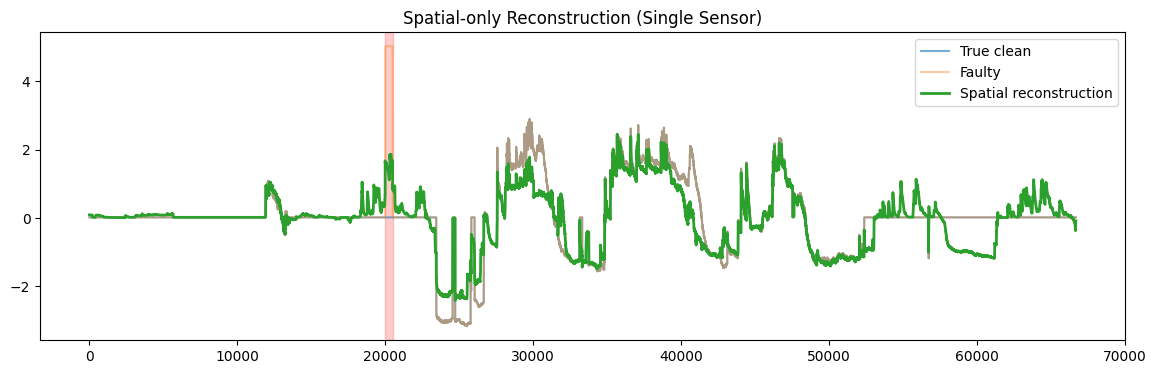

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_fault[:, sensor_idx], label="Faulty", alpha=0.4)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial reconstruction", linewidth=2)

plt.axvspan(t_start, t_end, color="red", alpha=0.2)
plt.legend()
plt.title("Spatial-only Reconstruction (Single Sensor)")
plt.show()


In [58]:
rmse_spatial_fault_window = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)


# Rule-based Temporal + Spatial

In [59]:
def compute_trust_weights(fault_len, max_len=200):
    """
    fault_len: how long the current fault has lasted
    """
    # Temporal trust decays with fault duration
    alpha_temp = np.exp(-fault_len / max_len)
    alpha_spatial = 1.0 - alpha_temp
    return alpha_temp, alpha_spatial


In [60]:
def fuse_reconstruction(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    p_fault,
    p_fault_threshold=0.6,
    eps=1e-6
):
    T, N = X_fault.shape
    X_fused = X_fault.clone()

    fault_duration = np.zeros(N, dtype=int)

    for t in range(T):
        for s in range(N):

            pf = p_fault[t, s]

            # update duration softly
            if pf > p_fault_threshold:
                fault_duration[s] += 1
            else:
                fault_duration[s] = 0

            # temporal vs spatial trust (slow dynamics)
            a_t, a_s = compute_trust_weights(fault_duration[s])

            # combined reconstructed belief
            recon = (
                a_t * X_temp_hat[t, s]
                + a_s * X_spatial_hat[t, s]
            )

            # 🔑 belief-aware fusion
            X_fused[t, s] = (
                (1.0 - pf) * X_fault[t, s]
                + pf * recon
            )

    return X_fused


In [61]:
X_fused = fuse_reconstruction(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    p_fault          # ✅ CORRECT
)


In [62]:
rmse_fused_fault_window = torch.sqrt(
    torch.mean(
        (X_fused[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)


In [63]:
print("RMSE temporal (fault window):", rmse_temporal_fault_window.item())
print("RMSE spatial  (fault window):", rmse_spatial_fault_window.item())
print("RMSE fused    (fault window):", rmse_fused_fault_window.item())


RMSE temporal (fault window): 4.3236565589904785
RMSE spatial  (fault window): 1.5060758590698242
RMSE fused    (fault window): 2.7537622451782227


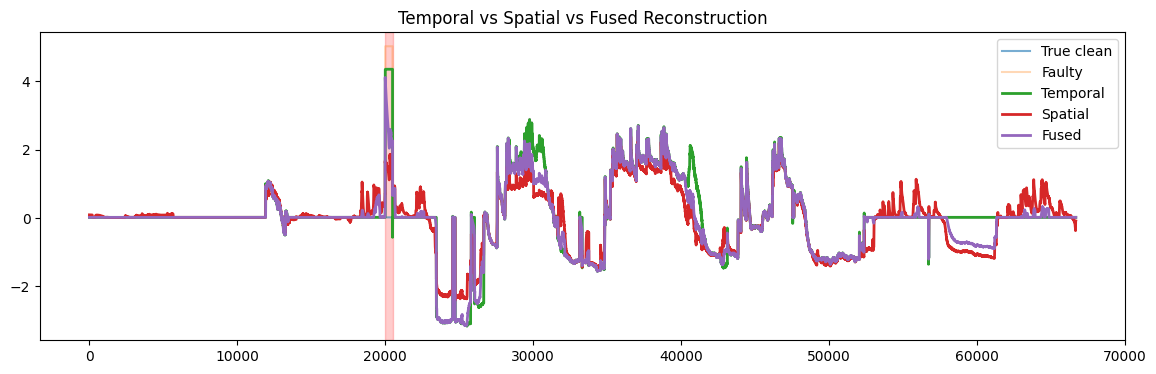

In [64]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_fault[:, sensor_idx], label="Faulty", alpha=0.3)
plt.plot(X_temp_hat[:, sensor_idx], label="Temporal", linewidth=2)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial", linewidth=2)
plt.plot(X_fused[:, sensor_idx], label="Fused", linewidth=2)

plt.axvspan(t_start, t_end, color="red", alpha=0.2)
plt.legend()
plt.title("Temporal vs Spatial vs Fused Reconstruction")
plt.show()


# Trust-Weighted Fusion

In [65]:
A_bin = (A > 0).float()
neighbors = {
    i: torch.where(A_bin[i])[0]
    for i in range(A.shape[0])
}

In [66]:
assert X_temp_hat.shape == X_fault.shape
assert X_spatial_hat.shape == X_fault.shape
assert X_fused.shape == X_fault.shape


In [67]:
# ================= TRUST SCORES (SAFE, SELF-CONTAINED) =================
eps = 1e-6

diff = torch.abs(X_fault - X_temp_hat)
scale = torch.median(diff, dim=0).values + eps

trust = torch.exp(-diff / scale)
trust = torch.clamp(trust, min=1e-6, max=1.0)

assert trust.shape == X_fault.shape
assert torch.isfinite(trust).all()

print(
    "trust stats →",
    "min:", trust.min().item(),
    "max:", trust.max().item(),
    "mean:", trust.mean().item()
)


trust stats → min: 9.999999974752427e-07 max: 1.0 mean: 0.9334750175476074


In [68]:
rmse_temporal_fault_window = torch.sqrt(
    torch.mean(
        (X_temp_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_spatial_fault_window = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_fused_fault_window = torch.sqrt(
    torch.mean(
        (X_fused[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE temporal (fault window):", rmse_temporal_fault_window.item())
print("RMSE spatial  (fault window):", rmse_spatial_fault_window.item())
print("RMSE fused    (fault window):", rmse_fused_fault_window.item())


RMSE temporal (fault window): 4.3236565589904785
RMSE spatial  (fault window): 1.5060758590698242
RMSE fused    (fault window): 2.7537622451782227


# Fault Recovery Dynamics

In [69]:
fault_flags_vis = p_fault > p_fault_threshold


In [70]:
# 🔑 convert once, use everywhere
p_fault_torch = torch.from_numpy(p_fault).float()

assert p_fault_torch.shape == (T, N)
assert torch.isfinite(p_fault_torch).all()


In [71]:
recovery_start = torch.zeros((T, N), dtype=torch.bool)

for i in range(N):
    for t in range(1, T):

        pf_prev = p_fault_torch[t-1, i]
        pf_now  = p_fault_torch[t, i]

        recovery_start[t, i] = (
            (pf_prev > p_fault_threshold) &
            (pf_now  <= p_fault_threshold)
        )


In [72]:
recovery_age = torch.zeros((T, N), dtype=torch.long)

for i in range(N):
    for t in range(1, T):

        pf_now  = p_fault[t, i]
        pf_prev = p_fault[t-1, i]

        # recovery starts when belief crosses downward
        if pf_prev > p_fault_threshold and pf_now <= p_fault_threshold:
            recovery_age[t, i] = 1

        # recovery continues while belief stays low
        elif recovery_age[t-1, i] > 0 and pf_now <= p_fault_threshold:
            recovery_age[t, i] = recovery_age[t-1, i] + 1

        else:
            recovery_age[t, i] = 0


In [73]:
RECOVERY_HORIZON = 24   # e.g. 1 day if hourly


In [74]:
def recovery_aware_fusion(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    p_fault,
    recovery_age,
    recovery_horizon=24,
    eps=1e-6
):
    T, N = X_fault.shape
    X_fused = X_fault.clone()

    for t in range(T):
        for i in range(N):

            pf = p_fault_coupled[t, i]

            # ---------- FAULT (HIGH CONFIDENCE) ----------
            if pf > 0.7:
                X_fused[t, i] = X_spatial_hat[t, i]
                continue

            # ---------- RECOVERY ----------
            if recovery_age[t, i] > 0:

                p_rec = min(recovery_age[t, i] / recovery_horizon, 1.0)

                # disagreements
                e_temp = torch.abs(X_temp_hat[t, i] - X_spatial_hat[t, i])
                e_sensor = torch.abs(X_fault[t, i] - X_spatial_hat[t, i])

                trust_temp = torch.exp(-e_temp)
                trust_sensor = torch.exp(-e_sensor)

                # safety gate
                if e_sensor > 2.0 * e_temp:
                    trust_sensor = torch.tensor(
                        0.0, device=X_fault.device
                    )

                # belief-aware weights
                w_spatial = 0.5 * pf
                w_temp    = 0.3 * p_rec * trust_temp * (1.0 - pf)
                w_sensor  = 0.2 * p_rec * trust_sensor * (1.0 - pf)

                Z = w_spatial + w_temp + w_sensor + eps
                w_spatial /= Z
                w_temp    /= Z
                w_sensor  /= Z

                X_fused[t, i] = (
                    w_spatial * X_spatial_hat[t, i]
                    + w_temp    * X_temp_hat[t, i]
                    + w_sensor  * X_fault[t, i]
                )

            # ---------- HEALTHY ----------
            else:
                X_fused[t, i] = (
                    (1.0 - pf) * X_fault[t, i]
                    + pf * X_spatial_hat[t, i]
                )

    return X_fused


In [75]:
X_fused_recovery = recovery_aware_fusion(
    X_fault,
    X_temp_hat,
    X_spatial_hat,
    p_fault,          # ✅ CORRECT
    recovery_age,
    RECOVERY_HORIZON
)


In [76]:
recovery_mask = (
    (recovery_age[:, sensor_idx] > 0) &
    (recovery_age[:, sensor_idx] <= RECOVERY_HORIZON)
)

rmse_recovery = torch.sqrt(
    torch.mean(
        (X_fused_recovery[recovery_mask, sensor_idx]
         - Y_true[recovery_mask, sensor_idx]) ** 2
    )
)

rmse_spatial_recovery = torch.sqrt(
    torch.mean(
        (X_spatial_hat[recovery_mask, sensor_idx]
         - Y_true[recovery_mask, sensor_idx]) ** 2
    )
)

print("RMSE recovery (fused):", rmse_recovery.item())
print("RMSE recovery (spatial):", rmse_spatial_recovery.item())


RMSE recovery (fused): 0.4188632071018219
RMSE recovery (spatial): 0.4972399175167084


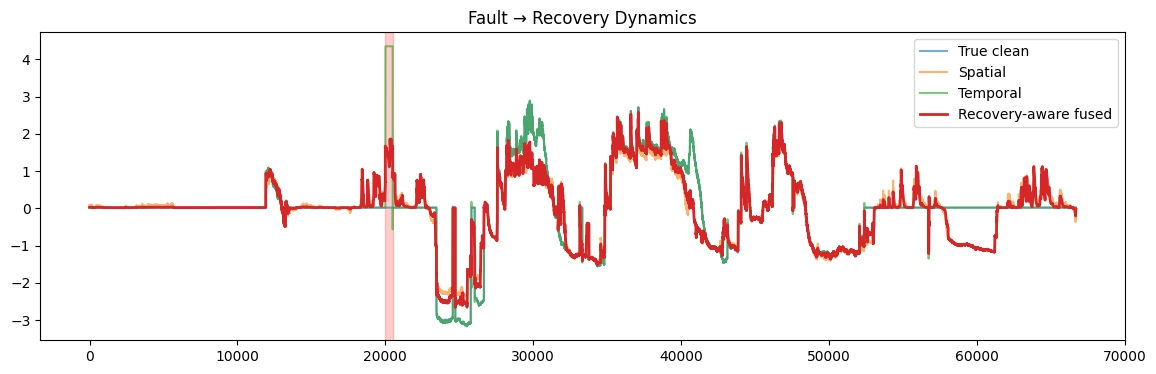

In [77]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial", alpha=0.6)
plt.plot(X_temp_hat[:, sensor_idx], label="Temporal", alpha=0.6)
plt.plot(X_fused_recovery[:, sensor_idx], label="Recovery-aware fused", linewidth=2)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Fault → Recovery Dynamics")
plt.show()


# Trust-Weighted Spatial Centroid

In [78]:
def compute_trust_scores(X_obs, X_temp_hat, health, eps=1e-6):
    diff = torch.abs(X_obs - X_temp_hat)

    scale = torch.median(diff, dim=0).values + eps
    agreement = torch.exp(-diff / scale)

    # 🔑 NEW: factor in health
    trust = agreement * health.unsqueeze(0)

    return torch.clamp(trust, min=1e-3, max=1.0)


In [79]:
# ================= TRUST SCORES =================
trust = compute_trust_scores(
    X_fault,
    X_temp_hat,
    health        # ✅ NEW ARGUMENT
)

assert trust.shape == X_fault.shape
assert torch.isfinite(trust).all()


In [80]:
# ================= CONVERT NEIGHBORS TO TORCH =================
nbr_idx_torch = torch.tensor(nbr_idx, dtype=torch.long)
nbr_dist_torch = torch.tensor(nbr_dist, dtype=torch.float32)

assert nbr_idx_torch.shape == nbr_dist_torch.shape


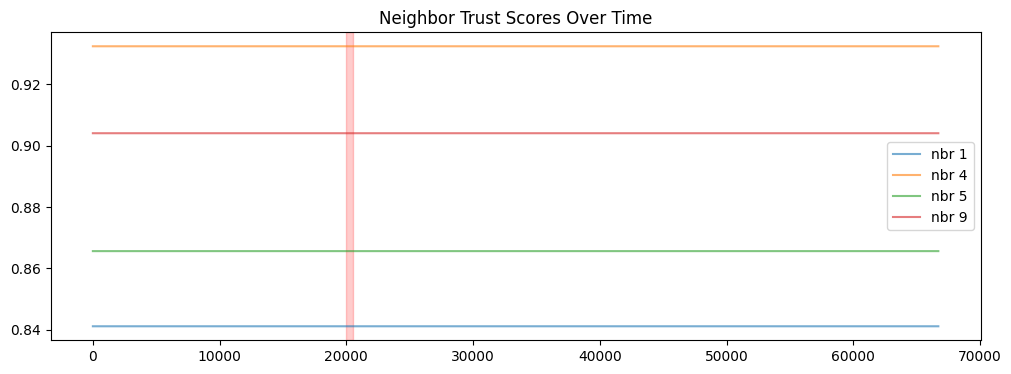

In [81]:
plt.figure(figsize=(12,4))
for n in nbr_idx[sensor_idx]:
    plt.plot(trust[:, n].cpu(), alpha=0.6, label=f"nbr {n}")

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.title("Neighbor Trust Scores Over Time")
plt.legend()
plt.show()


In [82]:
def spatial_reconstruct_trust_weighted(
    X_obs,
    X_temp_hat,
    p_fault_uncoupled,
    p_fault_coupled,
    nbr_idx,
    nbr_dist,
    health,
    eps=1e-6
):

    T, N = X_obs.shape
    X_hat = X_obs.clone()
    inv_dist = 1.0 / (nbr_dist + eps)

    for t in range(T):
        for s in range(N):

            nbrs = nbr_idx[s]
            geo_w = inv_dist[s]

            p_nbr = neighbor_fault_probability(
                t,
                s,
                X_obs,
                X_temp_hat,
                p_fault_uncoupled,   # ✅ Step-2 only
                nbr_idx,
                health
            )

            trust_nbr = torch.where(
                p_nbr > 0.5,
                torch.zeros_like(p_nbr),
                1.0 - p_nbr
            )

            w = geo_w * trust_nbr
            w = w / (w.sum() + eps)

            pf = p_fault_coupled[t, s]

            spatial_est = torch.sum(w * X_obs[t, nbrs])

            X_hat[t, s] = (1.0 - pf) * X_obs[t, s] + pf * spatial_est

    return X_hat


In [83]:
X_spatial_hat_trust = spatial_reconstruct_trust_weighted(
    X_fault,
    X_temp_hat,
    p_fault_uncoupled,
    p_fault_coupled,
    nbr_idx_torch,
    nbr_dist_torch,
    health
)



In [84]:
rmse_spatial_plain = torch.sqrt(
    torch.mean(
        (X_spatial_hat[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_spatial_trust = torch.sqrt(
    torch.mean(
        (X_spatial_hat_trust[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE spatial (distance only):", rmse_spatial_plain.item())
print("RMSE spatial (trust-weighted):", rmse_spatial_trust.item())


RMSE spatial (distance only): 1.5060758590698242
RMSE spatial (trust-weighted): 1.5060758590698242


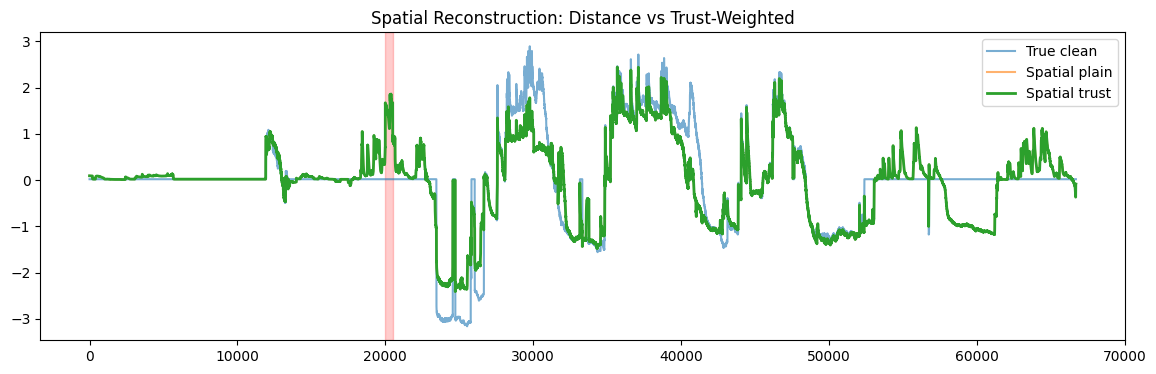

In [85]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_spatial_hat[:, sensor_idx], label="Spatial plain", alpha=0.6)
plt.plot(X_spatial_hat_trust[:, sensor_idx], label="Spatial trust", linewidth=2)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Spatial Reconstruction: Distance vs Trust-Weighted")
plt.show()


# Inject a Faulty Neighbor (Controlled Stress Test)

In [86]:
# =========================================================
# MULTI-NEIGHBOR SIMULTANEOUS FAULT INJECTION
# =========================================================

target = sensor_idx
neighbors_target = nbr_idx[target]   # (K,)

# ---- CONFIG ----
NUM_FAULTY_NEIGHBORS = 2   # try 2, then 3
NEIGHBOR_FAULT_MAG = 5.0

# select which neighbors fail (closest ones, worst case)
faulty_neighbors = neighbors_target[:NUM_FAULTY_NEIGHBORS]

print("Target sensor:", target)
print("Faulty neighbors:", faulty_neighbors.tolist())

# ---- inject faults ----
X_fault_nb = X_fault.clone()

for n in faulty_neighbors:
    X_fault_nb[FAULT_START:FAULT_END, n] += NEIGHBOR_FAULT_MAG

assert torch.isfinite(X_fault_nb).all()


Target sensor: 2
Faulty neighbors: [1, 4]


In [87]:
# ================= TRUST (WITH FAULTY NEIGHBOR) =================
diff = torch.abs(X_fault_nb - X_temp_hat)
scale = torch.median(diff, dim=0).values + 1e-6

trust_nb = torch.exp(-diff / scale)
trust_nb = torch.clamp(trust_nb, min=1e-6, max=1.0)

print(
    "trust stats (neighbor-fault case) →",
    trust_nb.min().item(),
    trust_nb.mean().item()
)


trust stats (neighbor-fault case) → 9.999999974752427e-07 0.9319758415222168


In [88]:
X_spatial_nb = spatial_reconstruct(
    X_fault_nb,
    X_temp_hat,
    p_fault_uncoupled,
    p_fault_coupled,
    nbr_idx_torch,
    nbr_dist_torch,
    health
)


In [89]:
rmse_spatial_nb = torch.sqrt(
    torch.mean(
        (X_spatial_nb[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE spatial (belief-based, neighbor faulty):", rmse_spatial_nb.item())


RMSE spatial (belief-based, neighbor faulty): 4.2978997230529785


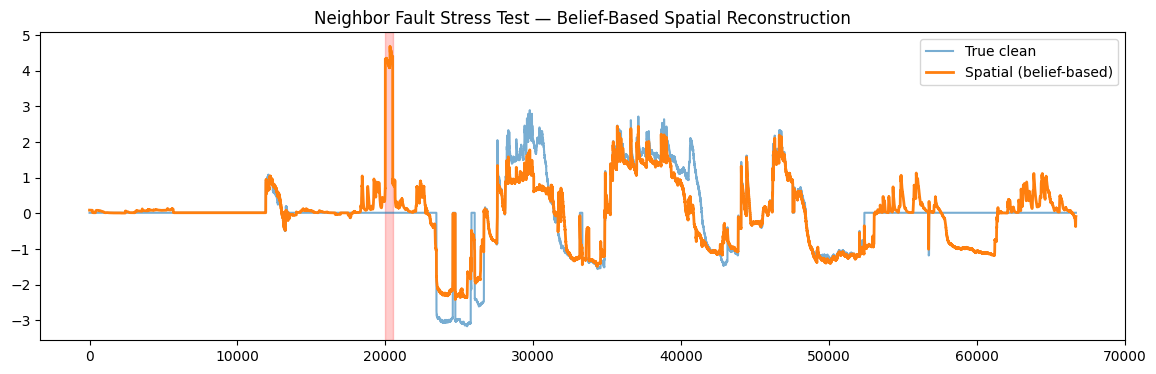

In [90]:
plt.figure(figsize=(14,4))
plt.plot(Y_true[:, sensor_idx], label="True clean", alpha=0.6)
plt.plot(X_spatial_nb[:, sensor_idx], label="Spatial (belief-based)", linewidth=2)

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Neighbor Fault Stress Test — Belief-Based Spatial Reconstruction")
plt.show()


In [91]:
# average trust during fault window
avg_trust_fault = trust_nb[mask_fault_window].mean(dim=0)

for n in nbr_idx[sensor_idx]:
    print(f"Neighbor {n}: avg trust = {avg_trust_fault[n].item():.3f}")


Neighbor 1: avg trust = 0.000
Neighbor 4: avg trust = 0.000
Neighbor 5: avg trust = 1.000
Neighbor 9: avg trust = 1.000


In [92]:
for n in faulty_neighbors:
    delta = (
        X_fault_nb[FAULT_START:FAULT_END, n]
        - X_fault[FAULT_START:FAULT_END, n]
    ).mean()
    print(f"Injected delta for neighbor {n}: {delta.item():.2f}")


Injected delta for neighbor 1: 5.00
Injected delta for neighbor 4: 5.00


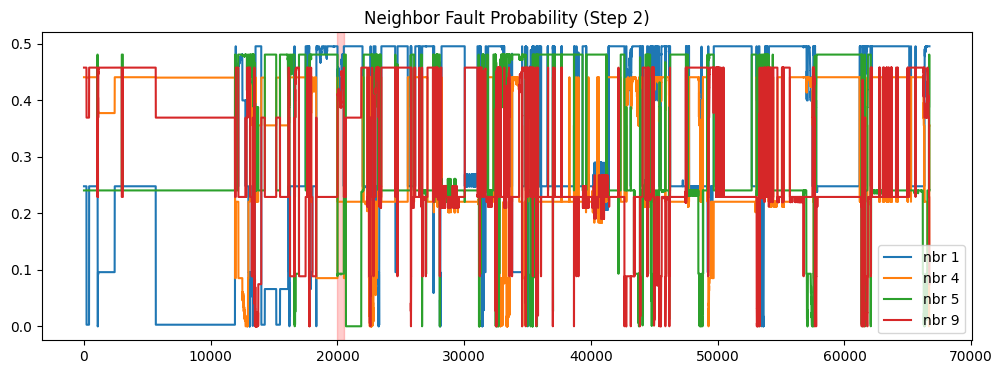

In [93]:
plt.figure(figsize=(12,4))
for j in nbr_idx[sensor_idx]:
    probs = []
    for t in range(T):
        p = neighbor_fault_probability(
            t,
            sensor_idx,
            X_fault_nb,
            X_temp_hat,
            p_fault_uncoupled,
            nbr_idx_torch,
            health
        )
        probs.append(p[nbr_idx[sensor_idx] == j].item())

    plt.plot(probs, label=f"nbr {j}")

plt.axvspan(FAULT_START, FAULT_END, color="red", alpha=0.2)
plt.legend()
plt.title("Neighbor Fault Probability (Step 2)")
plt.show()


In [94]:
fault_window = slice(FAULT_START, FAULT_END)

p_faulty, p_healthy = [], []

for t in range(FAULT_START, FAULT_END):

    p_nbr = neighbor_fault_probability(
        t,
        sensor_idx,
        X_fault_nb,
        X_temp_hat,
        p_fault,
        nbr_idx_torch,
        health
    )

    for k, j in enumerate(nbr_idx[sensor_idx]):
        if j in faulty_neighbors:
            p_faulty.append(p_nbr[k].item())
        else:
            p_healthy.append(p_nbr[k].item())

print("Step-2 neighbor belief (FIXED):")
print("  faulty  :", np.mean(p_faulty))
print("  healthy :", np.mean(p_healthy))


Step-2 neighbor belief (FIXED):
  faulty  : 0.33104538306593895
  healthy : 0.25408699133247137


In [95]:
# ================= BASELINE: SPATIAL WITHOUT STEP 2 =================
X_spatial_plain_nb = X_fault_nb.clone()

inv_dist = 1.0 / (nbr_dist_torch + 1e-6)   # (N, K)

for t in range(T):
    for s in range(N):
        nbrs = nbr_idx_torch[s]
        w = inv_dist[s]
        w = w / (w.sum() + 1e-6)

        X_spatial_plain_nb[t, s] = torch.sum(
            w * X_fault_nb[t, nbrs]
        )

# sanity
assert X_spatial_plain_nb.shape == X_fault_nb.shape
assert torch.isfinite(X_spatial_plain_nb).all()


In [96]:
rmse_plain = torch.sqrt(
    torch.mean(
        (X_spatial_plain_nb[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

rmse_step2 = torch.sqrt(
    torch.mean(
        (X_spatial_nb[mask_fault_window, sensor_idx]
         - Y_true[mask_fault_window, sensor_idx]) ** 2
    )
)

print("RMSE spatial (no Step 2):", rmse_plain.item())
print("RMSE spatial (with Step 2):", rmse_step2.item())


RMSE spatial (no Step 2): 4.316773891448975
RMSE spatial (with Step 2): 4.2978997230529785


In [97]:
def spatial_belief_roughness(p_fault, neighbors):
    T, N = p_fault.shape
    rough = []

    for i in range(N):
        for j in neighbors[i]:
            rough.append(
                np.mean(np.abs(p_fault[:, i] - p_fault[:, j]))
            )
    return np.mean(rough)


In [98]:
r_before = spatial_belief_roughness(p_fault_raw, neighbors)
r_after  = spatial_belief_roughness(p_fault, neighbors)

print("Roughness before Step 3:", r_before)
print("Roughness after  Step 3:", r_after)


Roughness before Step 3: 0.27973557
Roughness after  Step 3: 0.1323279


In [99]:
outside = np.ones(T, dtype=bool)
outside[FAULT_START:FAULT_END] = False

fp_before = (p_fault_raw[outside] > p_fault_threshold).mean()
fp_after  = (p_fault[outside]     > p_fault_threshold).mean()

print("False positive rate before:", fp_before)
print("False positive rate after :", fp_after)


False positive rate before: 0.2774412808700249
False positive rate after : 0.19257306849935804


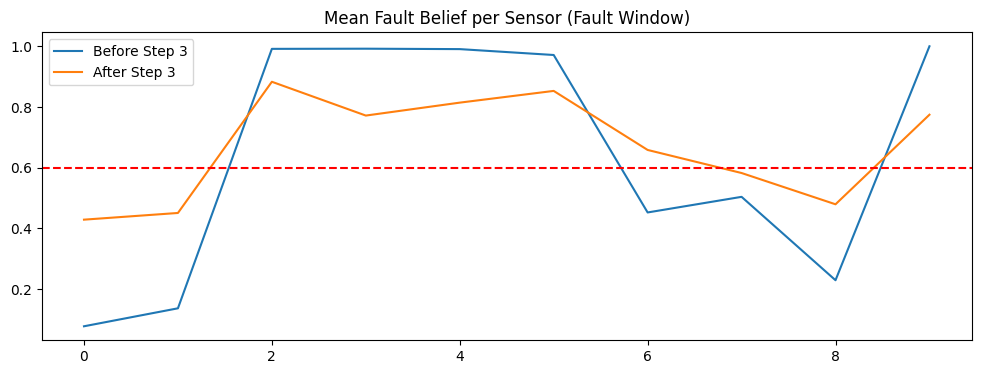

In [100]:
inside = slice(FAULT_START, FAULT_END)

mean_pf = p_fault[inside].mean(axis=0)
mean_pf_raw = p_fault_raw[inside].mean(axis=0)

plt.figure(figsize=(12,4))
plt.plot(mean_pf_raw, label="Before Step 3")
plt.plot(mean_pf, label="After Step 3")
plt.axhline(p_fault_threshold, color="red", linestyle="--")
plt.legend()
plt.title("Mean Fault Belief per Sensor (Fault Window)")
plt.show()


In [101]:
auc_before = roc_auc_score(
    fault_gt.cpu().numpy().ravel(),
    p_fault_raw.ravel()
)

auc_after = roc_auc_score(
    fault_gt.cpu().numpy().ravel(),
    p_fault.ravel()
)

print("ROC-AUC before Step 3:", auc_before)
print("ROC-AUC after  Step 3:", auc_after)


ROC-AUC before Step 3: 0.955532423674143
ROC-AUC after  Step 3: 0.9769942870002251
